6/25/26

# v10 — Fine-tuning: Full Fine-tuning vs. LoRA

This notebook picks up where **v9** left off. Instead of building a new model from scratch, we take the
**already-trained v9 checkpoint** (a tiny char-level GPT pretrained on the Harry Potter corpus) and put it
through four exercises:

1. Generate from the pretrained model, starting from the word `"Harry"`.
2. Feed it a line from a *different* dataset — Shakespeare — and see how it does out of the box.
3. **Full fine-tuning**: continue training *all* of its weights on the Shakespeare text for 1000 steps.
4. **LoRA fine-tuning**: freeze the pretrained weights and train a rank-4 low-rank adapter instead, for the
   same number of steps.

Along the way we'll compare how many parameters each approach actually updates, and what each one does to
the model's grip on Harry Potter (does it forget?).

The model architecture (`Head`, `MultiHeadAttention`, `FeedForward`, `TransformerBlock`,
`BigramLanguageModel`) is identical to v9 — we only need it here to reconstruct the class and load the
saved weights into it.

**Note on runtime:** this notebook trains on CPU using the same non-vectorized attention implementation as
v9. With the settings below, 1000 fine-tuning steps takes roughly 20–30 minutes per run (so ~45–60 minutes
total for the full + LoRA runs together) on a typical laptop. Lower `finetune_max_iters` for a quick
smoke test.


## 1. Imports


In [1]:
import os
import torch
import torch.nn as nn
from torch.nn import functional as F

## 2. Hyperparameters

The architecture settings (`emb_size`, `block_size`, `num_layers`, `num_heads`, `dropout`) must match v9
exactly — otherwise a freshly constructed model won't have the same shapes as the weights saved in the
checkpoint. Below that are the fine-tuning-specific settings: how many steps, how often to check the loss,
and how long a sample to print.


In [2]:
# # architecture — must match v9 exactly so the checkpoint's weights line up
# emb_size = 128
# block_size = 256
# num_layers = 4
# num_heads = 8
# dropout = 0.05
# device = 'cuda' if torch.cuda.is_available() else 'cpu'
# seed = 42
# torch.manual_seed(seed)

# # fine-tuning settings
# batch_size = 64
# finetune_max_iters = 1000   # steps for both full fine-tuning and LoRA, as requested
# finetune_lr = 1e-4
# eval_interval = 250
# eval_iters = 50
# gen_tokens = 300            # length of the sample continuations we'll print

# print(device)

In [3]:
# Sabine's version of the above block that does hardware detection (that way on Mac it uses GPU if available rather than CPU default)
# Detect best available device (CUDA>MPS>CPU) and set DataLoader workers accordingly

# architecture — must match v9 exactly so the checkpoint's weights line up
emb_size = 128
block_size = 256
num_layers = 4
num_heads = 8
dropout = 0.05
seed = 42
torch.manual_seed(seed)

# fine-tuning settings
batch_size = 64
finetune_max_iters = 1000   # steps for both full fine-tuning and LoRA, as requested
finetune_lr = 1e-4
eval_interval = 250
eval_iters = 50
gen_tokens = 300            # length of the sample continuations we'll print

if torch.cuda.is_available():
    device = torch.device("cuda")
    total_cores = os.cpu_count()
    NUM_WORKERS = min(8, max(1, total_cores - 2))

elif torch.backends.mps.is_available():
    device = torch.device("mps")
    NUM_WORKERS = 0  # MPS + multiprocessing can hang

else:
    device = torch.device("cpu")
    NUM_WORKERS = 0

print(f"Using device: {device}")
torch.manual_seed(seed)

Using device: cuda


## 3. Rebuild the Harry Potter vocabulary

The checkpoint stores the model's *weights*, not the character-to-index mapping it was trained with.
Since `chars = sorted(set(text))` is deterministic, re-running it on the same `harry_potter.txt` regenerates
exactly the same 71-character vocabulary the model was trained with — so we rebuild `stoi`/`itos` from the
source text rather than guessing.


In [4]:
with open('./data/harry_potter.txt', encoding='utf-8') as f:
    hp_text = f.read()

chars = sorted(list(set(hp_text)))
vocab_size = len(chars)
hp_vocab = set(chars)

stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}
encode = lambda s: [stoi[c] for c in s]
decode = lambda l: ''.join([itos[i] for i in l])

print(f"vocab_size: {vocab_size}")
print(''.join(chars))

vocab_size: 71
 !.0123456789?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz~‘•■□


## 4. The model (recap from v9)

Unchanged from v9 — `Head`, `MultiHeadAttention`, `FeedForward`, `TransformerBlock`, `BigramLanguageModel`.
The only difference is `@torch.no_grad()` added to `generate` (v9 didn't have it), purely so sampling
doesn't waste memory building a backward graph it'll never use — it has no effect on the generated text.


In [5]:
class Head(nn.Module):
    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(emb_size, head_size, bias=False)
        self.query = nn.Linear(emb_size, head_size, bias=False)
        self.value = nn.Linear(emb_size, head_size, bias=False)
        self.att_dropout = nn.Dropout(dropout)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))

    def forward(self, x):
        B, T, C = x.shape
        key = self.key(x)
        query = self.query(x)
        dot_products = query @ key.transpose(-2, -1) * C ** -0.5
        dot_products = dot_products.masked_fill(self.tril[:T, :T] == 0, float('-inf'))
        weights = F.softmax(dot_products, dim=-1)
        weights = self.att_dropout(weights)
        value = self.value(x)
        out = weights @ value
        return out


class MultiHeadAttention(nn.Module):
    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(emb_size, emb_size)
        self.res_dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = torch.cat([head(x) for head in self.heads], dim=-1)
        x = self.res_dropout(self.proj(x))
        return x


class FeedForward(nn.Module):
    def __init__(self, emb_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(emb_size, 4 * emb_size),
            nn.ReLU(),
            nn.Linear(4 * emb_size, emb_size),
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.dropout(self.net(x))


class TransformerBlock(nn.Module):
    def __init__(self, embd_size, num_heads):
        super().__init__()
        head_size = embd_size // num_heads
        self.att_head = MultiHeadAttention(num_heads, head_size)
        self.feedforward = FeedForward(emb_size)
        self.ln1 = nn.LayerNorm(emb_size)
        self.ln2 = nn.LayerNorm(emb_size)

    def forward(self, x):
        x = x + self.att_head(self.ln1(x))
        x = x + self.feedforward(self.ln2(x))
        return x


class BigramLanguageModel(nn.Module):
    def __init__(self, vocab_size, emb_size):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, emb_size)
        self.position_embedding_table = nn.Embedding(block_size, emb_size)
        self.blocks = nn.Sequential(*[TransformerBlock(emb_size, num_heads=num_heads) for _ in range(num_layers)])
        self.linear_head = nn.Linear(emb_size, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        tok_emb = self.token_embedding_table(idx)
        pos_emb = self.position_embedding_table(torch.arange(T, device=idx.device))
        x = tok_emb + pos_emb
        x = self.blocks(x)
        logits = self.linear_head(x)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B * T, C)
            targets = targets.view(B * T)
            loss = F.cross_entropy(logits, targets)
        return logits, loss

    @torch.no_grad() # New addition in v10!
    def generate(self, idx, max_new_tokens):
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -block_size:]
            logits, loss = self(idx_cond)
            logits = logits[:, -1, :]
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx

## 5. Load the v9 checkpoint

`torch.save` in v9 wrote a dict with the model's `state_dict`, optimizer state, and training metadata — we
only need `model` and the metadata here. We build a fresh `BigramLanguageModel` and load the saved weights
into it; the shapes have to match exactly (`vocab_size=71`, `emb_size=128`, ...), which is why the
hyperparameters above had to reproduce v9's settings precisely.


In [6]:
ckpt_path = './output/v9_ckpt.pt'
ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)

print(f"checkpoint trained for {ckpt['iter_num']} iters, best val loss {ckpt['best_val_loss'].item():.4f}")

base_model = BigramLanguageModel(vocab_size, emb_size).to(device)
base_model.load_state_dict(ckpt['model'])

n_params = sum(p.numel() for p in base_model.parameters())
print(f"{n_params / 1e6:.3f}M parameters loaded")

checkpoint trained for 9500 iters, best val loss 1.3527
0.843M parameters loaded


In [18]:
# see base model (pre lora) architecture
from torchinfo import summary
summary(base_model, input_size=(batch_size, block_size), dtypes=[torch.long])

Layer (type:depth-idx)                        Output Shape              Param #
BigramLanguageModel                           [64, 256, 71]             --
├─Embedding: 1-1                              [64, 256, 128]            9,088
├─Embedding: 1-2                              [256, 128]                32,768
├─Sequential: 1-3                             [64, 256, 128]            --
│    └─TransformerBlock: 2-1                  [64, 256, 128]            --
│    │    └─LayerNorm: 3-1                    [64, 256, 128]            256
│    │    └─MultiHeadAttention: 3-2           [64, 256, 128]            65,664
│    │    └─LayerNorm: 3-3                    [64, 256, 128]            256
│    │    └─FeedForward: 3-4                  [64, 256, 128]            131,712
│    └─TransformerBlock: 2-2                  [64, 256, 128]            --
│    │    └─LayerNorm: 3-5                    [64, 256, 128]            256
│    │    └─MultiHeadAttention: 3-6           [64, 256, 128]            65,6

## 6. A small helper for sampling

`model.eval()` turns dropout off so sampling isn't also fighting dropout noise (it's still stochastic from
`torch.multinomial`); `model.train()` restores it afterwards in case we keep training the same object.


In [7]:
def generate_from(model, prompt, max_new_tokens=gen_tokens):
    model.eval()
    context = torch.tensor([encode(prompt)], dtype=torch.long, device=device)
    out = model.generate(context, max_new_tokens=max_new_tokens)[0].tolist()
    model.train()
    return decode(out)

## 7. Step 1 — generate from "Harry"

This is the pretrained v9 model exactly as it came off the Harry Potter training run — no fine-tuning yet.


In [8]:
print(generate_from(base_model, "Harry "))

Harry could need all over .Excty lears than that was for a selep of Ron kiddd reaming it not do is soting by to darch and skettle of their real of the other .Hermione blood boys to get to them a said Dudley to green .Then primily greent with Dirledore .Perhaps there back .Harry croubted to Mainimy came to


In [9]:
print(generate_from(base_model, "Voldemort "))

Voldemort her said and down and out all over impoirning in tomortabables .Nobody seemed to that night that would belme is running a sice feather .With Eard ?said Ron said Hermione go .Finred Bagman act over he warned and curredtable .Henks eyes curse away on take of scome without at Harry die .I usem to use s


## 8. Step 2 — the same model on a Shakespeare line

Shakespeare's text uses characters the model has never seen — commas, colons, semicolons, apostrophes,
ampersands, newlines — none of which exist in the 71-character Harry Potter vocabulary above. Since
`token_embedding_table` and `linear_head` are both sized to `vocab_size=71`, the model is *physically
incapable* of reading or producing characters outside that set — that's a constraint fine-tuning alone
can't fix, since it would mean resizing the embedding and output layers. To keep things simple we strip
out anything outside the existing vocabulary before encoding, the same kind of cleanup the original
`harry_potter.txt` already went through (no commas or newlines in there either).


In [10]:
with open('./data/shakespeare.txt', encoding='utf-8') as f:
    shakespeare_text = f.read()


def clean_to_vocab(s):
    return ''.join(c for c in s if c in hp_vocab)


shakespeare_line = "Before we proceed any further, hear me speak."
clean_line = clean_to_vocab(shakespeare_line)
print(f"original: {shakespeare_line!r}")
print(f"cleaned : {clean_line!r}")
print()
print(generate_from(base_model, clean_line))

original: 'Before we proceed any further, hear me speak.'
cleaned : 'Before we proceed any further hear me speak.'

Before we proceed any further hear me speak.Heres was looking gazed .Is just a visionals sitches outside not before to Hall ather crimely .Something was sealep as though he come the delings felter home and vanise and were to dreanning black of himself been about them floody was now .My would saw bett you are because yeh didnt have abounclary 


## 9. What just happened

Even seeded with a Shakespeare line, the continuation drifts back into Harry-Potter-flavored prose —
character names, places, and turns of phrase straight out of the pretraining corpus. The model has no
notion of *Shakespeare* as a style; all it has is the one statistical pattern it was trained on. That's the
gap fine-tuning is meant to close.


## 10. Preparing the Shakespeare data for fine-tuning

Same `encode`/`decode`/90-10 split recipe as v9, just pointed at the (vocabulary-cleaned) Shakespeare text
instead of Harry Potter. We write a fresh `get_batch_shakespeare` / `estimate_loss_shakespeare` pair since
v9's versions were scoped to the Harry Potter `train_data`/`val_data` we never recreated here.


In [11]:
shakespeare_clean = clean_to_vocab(shakespeare_text)
print(f"Shakespeare: {len(shakespeare_text)} chars -> {len(shakespeare_clean)} after dropping "
      f"out-of-vocab characters")

sp_data = torch.tensor(encode(shakespeare_clean), dtype=torch.long)
n = int(0.9 * len(sp_data))
sp_train_data = sp_data[:n]
sp_val_data = sp_data[n:]


def get_batch_shakespeare(split):
    data = sp_train_data if split == 'train' else sp_val_data
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i + block_size] for i in ix])
    y = torch.stack([data[i + 1:i + block_size + 1] for i in ix])
    x, y = x.to(device), y.to(device)
    return x, y


@torch.no_grad()
def estimate_loss_shakespeare(model):
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch_shakespeare(split)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

Shakespeare: 1115394 chars -> 1033516 after dropping out-of-vocab characters


*note dealing with out of vocab chars*

## 11. Step 3 — Full fine-tuning (1000 steps)

Full fine-tuning means exactly what it sounds like: start from the pretrained weights, then keep
training — but now on Shakespeare, with every parameter still trainable. We load a *fresh* copy of the v9
weights (rather than continuing to train `base_model` from the cells above) so this run starts from the
same clean baseline as the LoRA run in step 13, making the two comparable. We also drop the learning rate
from v9's `3e-4` to `1e-4` — a common fine-tuning practice, since large steps risk wrecking the pretrained
weights before the new data gets a chance to shape them.


In [12]:
full_ft_model = BigramLanguageModel(vocab_size, emb_size).to(device)
full_ft_model.load_state_dict(ckpt['model'])

n_trainable_full = sum(p.numel() for p in full_ft_model.parameters() if p.requires_grad)
n_total_full = sum(p.numel() for p in full_ft_model.parameters())
print(f"full fine-tuning: {n_trainable_full:,} / {n_total_full:,} parameters trainable (100%)")

optimizer_full = torch.optim.AdamW(full_ft_model.parameters(), lr=finetune_lr)

for it in range(finetune_max_iters):
    if it % eval_interval == 0 or it == finetune_max_iters - 1:
        losses = estimate_loss_shakespeare(full_ft_model)
        print(f"step {it}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

    xb, yb = get_batch_shakespeare('train')
    logits, loss = full_ft_model(xb, yb)
    optimizer_full.zero_grad(set_to_none=True)
    loss.backward()
    optimizer_full.step()

full fine-tuning: 842,567 / 842,567 parameters trainable (100%)
step 0: train loss 2.4116, val loss 2.4856
step 250: train loss 1.7699, val loss 1.8674
step 500: train loss 1.6971, val loss 1.8294
step 750: train loss 1.6575, val loss 1.8127
step 999: train loss 1.6284, val loss 1.8030


## 12. Sampling the fully fine-tuned model

Same Shakespeare line as step 2, plus the `"Harry"` prompt from step 1 — the second one tells us whether
full fine-tuning came at the cost of forgetting Harry Potter.


In [13]:
print("--- Shakespeare prompt ---")
print(generate_from(full_ft_model, clean_line))
print()
print("--- 'Harry' prompt (forgetting check) ---")
print(generate_from(full_ft_model, "Harry"))

--- Shakespeare prompt ---
Before we proceed any further hear me speak.VERWhy do not here. Clenceaks be eyes are thee time to me by men theere? VIORHunter my nor some of thynnesd yield may and from a foot.LordWill I have a shall beauty stayAnd spendis not leaveHas none Mights to be for a manUpy books souring mish whom oldst riset yet suit?And it that I fiet is father o

--- 'Harry' prompt (forgetting check) ---
Harry his fatherTo criatorTo clot put of his family breath no stay for them to to hus bly kingHowYould have hath lord foot hit. I gentlemes bot from my deserYone not much my rightThat not show they lied not as thus itSir world!I mean.She hoped to thisInk good upon highnifices frome thy lightThrewice the 


*Now we will discuss parameter efficient tuning. we are using rank=4 for demonstrative purposes*

*note that you don't have to use this code, hugging face has a wrapper for this, but we want to see here how the architecture actually works*

## 13. Step 4 — LoRA fine-tuning (rank=4)

LoRA (Low-Rank Adaptation) freezes the pretrained weight matrix `W` and instead learns a small additive
update `ΔW = B @ A`, where `A` is `r × in_features` and `B` is `out_features × r`. With `r=4` and
`emb_size=128`, each adapted `128×128` projection (16,512 frozen params, bias included) gets only
`4×128 + 128×4 = 1,024` trainable parameters alongside it — about 6% of the size of the layer it's attached
to. The frozen base weight never changes; only the low-rank correction does, which is also part of why LoRA
tends to forget less: the original capability is still sitting right there underneath.

We wrap every `nn.Linear` inside the attention heads (`key`, `query`, `value`, `proj`) and the feed-forward
block (`net[0]`, `net[2]`) in a `LoRALinear` module. `lora_B` is initialized to all zeros, so before any
training the adapter contributes nothing — `LoRALinear` starts out mathematically identical to the frozen
base layer.


In [14]:
class LoRALinear(nn.Module):
    def __init__(self, base_linear, r=4, alpha=8):
        super().__init__()
        self.base = base_linear
        for p in self.base.parameters():
            p.requires_grad = False

        self.r = r
        self.scaling = alpha / r
        self.lora_A = nn.Parameter(torch.zeros(r, base_linear.in_features))
        self.lora_B = nn.Parameter(torch.zeros(base_linear.out_features, r))
        nn.init.kaiming_uniform_(self.lora_A, a=5 ** 0.5)  # lora_B stays zero -> adapter starts as a no-op

    def forward(self, x):
        base_out = self.base(x)
        lora_out = (x @ self.lora_A.T) @ self.lora_B.T
        return base_out + self.scaling * lora_out


def add_lora(model, r=4, alpha=8):
    for p in model.parameters():
        p.requires_grad = False
    for block in model.blocks:
        attn = block.att_head
        for head in attn.heads:
            head.key = LoRALinear(head.key, r, alpha)
            head.query = LoRALinear(head.query, r, alpha)
            head.value = LoRALinear(head.value, r, alpha)
        attn.proj = LoRALinear(attn.proj, r, alpha)

        ff = block.feedforward
        ff.net[0] = LoRALinear(ff.net[0], r, alpha)
        ff.net[2] = LoRALinear(ff.net[2], r, alpha)
    return model

In [19]:
# see model architecture after lora add
summary(lora_model, input_size=(batch_size, block_size), dtypes=[torch.long])

Layer (type:depth-idx)                             Output Shape              Param #
BigramLanguageModel                                [64, 256, 71]             --
├─Embedding: 1-1                                   [64, 256, 128]            (9,088)
├─Embedding: 1-2                                   [256, 128]                (32,768)
├─Sequential: 1-3                                  [64, 256, 128]            --
│    └─TransformerBlock: 2-1                       [64, 256, 128]            --
│    │    └─LayerNorm: 3-1                         [64, 256, 128]            (256)
│    │    └─MultiHeadAttention: 3-2                [64, 256, 128]            80,512
│    │    └─LayerNorm: 3-3                         [64, 256, 128]            (256)
│    │    └─FeedForward: 3-4                       [64, 256, 128]            136,832
│    └─TransformerBlock: 2-2                       [64, 256, 128]            --
│    │    └─LayerNorm: 3-5                         [64, 256, 128]            (256)
│    │

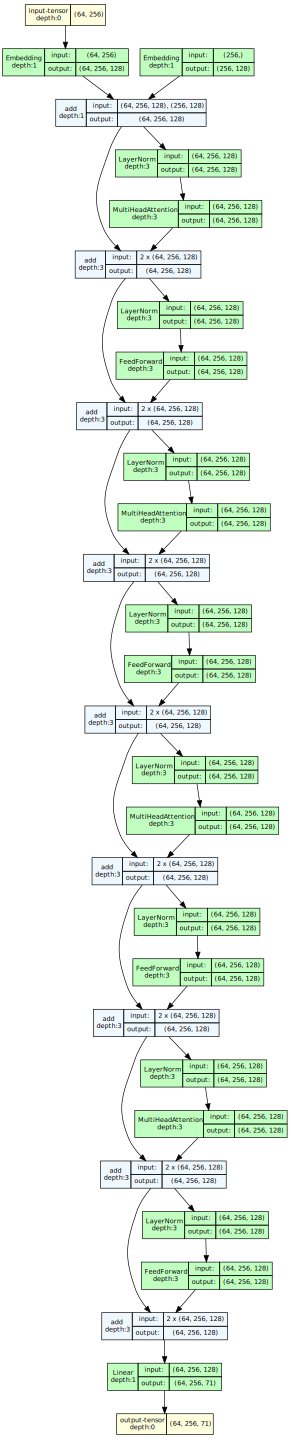

In [20]:
from torchview import draw_graph
graph = draw_graph(lora_model, input_size=(batch_size, block_size), dtypes=[torch.long], device=device)
graph.visual_graph

## 14. Training the LoRA adapter (1000 steps)

Again starting from a fresh copy of the v9 weights. The optimizer only ever sees `lora_A`/`lora_B`
parameters — `requires_grad=False` on everything else means `loss.backward()` never computes a gradient
for the frozen base weights.


In [15]:
lora_model = BigramLanguageModel(vocab_size, emb_size).to(device)
lora_model.load_state_dict(ckpt['model'])
lora_model = add_lora(lora_model, r=4, alpha=8)
lora_model = lora_model.to(device)  # ADDED BY SABINE to fix error (RuntimeError: Expected all tensors to be on the same device, but got mat2 is on cpu, different from other tensors on cuda:0 (when checking argument in method wrapper_CUDA_mm))


n_trainable_lora = sum(p.numel() for p in lora_model.parameters() if p.requires_grad)
n_total_lora = sum(p.numel() for p in lora_model.parameters())
print(f"LoRA fine-tuning: {n_trainable_lora:,} / {n_total_lora:,} parameters trainable "
      f"({100 * n_trainable_lora / n_total_lora:.2f}%)")
print(f"compare: full fine-tuning trained {n_trainable_full:,} parameters "
      f"({n_trainable_full / n_trainable_lora:.1f}x more than LoRA)")

optimizer_lora = torch.optim.AdamW(
    [p for p in lora_model.parameters() if p.requires_grad], lr=finetune_lr
)

for it in range(finetune_max_iters):
    if it % eval_interval == 0 or it == finetune_max_iters - 1:
        losses = estimate_loss_shakespeare(lora_model)
        print(f"step {it}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

    xb, yb = get_batch_shakespeare('train')
    logits, loss = lora_model(xb, yb)
    optimizer_lora.zero_grad(set_to_none=True)
    loss.backward()
    optimizer_lora.step()

LoRA fine-tuning: 79,872 / 922,439 parameters trainable (8.66%)
compare: full fine-tuning trained 842,567 parameters (10.5x more than LoRA)
step 0: train loss 2.3988, val loss 2.4796
step 250: train loss 2.0281, val loss 2.0600
step 500: train loss 1.9541, val loss 1.9917
step 750: train loss 1.9125, val loss 1.9662
step 999: train loss 1.8905, val loss 1.9372


## 15. Sampling the LoRA fine-tuned model


In [16]:
print("--- Shakespeare prompt ---")
print(generate_from(lora_model, clean_line))
print()
print("--- 'Harry' prompt (forgetting check) ---")
print(generate_from(lora_model, "Harry"))

--- Shakespeare prompt ---
Before we proceed any further hear me speak.CAAhHis which many of his with mind the betterl I know hear lo.Than you to his ear thou this hope faint!Thats that every gustens!AURILUTHIm feet seew. DINODOEYONOh course to My offityvild tward good their feel afterWhat grows of front of the ruius the browlardSence and would tell have grantI is SO w

--- 'Harry' prompt (forgetting check) ---
Harry this love extratolus is not in these my brost liprably around birds but CareAnd I exprectin of the words nor!Ron hese asketThe passent and loud my at pay foockAnd nenbly soul again.Y ILIWo deal what he schall terravestSeake thundbling alaiss.IMINARAZERICPARYASTICKICANsOSpe thought adman once hall t


*Note about **catastrophic forgetting**: now it won't even generate good Harry text (which it could do in v9). so fine tuning, even full fine tuning on one dataset broke the model here*

## 16. Checkpoint size: full model vs. adapter-only

One more practical difference: a full fine-tuning checkpoint has to store every parameter, while a LoRA
checkpoint only needs the small `lora_A`/`lora_B` matrices — the frozen base weights are unchanged, so they
don't need to be saved again for every adapter.


In [17]:
torch.save(full_ft_model.state_dict(), './output/v10_shakespeare_full_ft.pt')

lora_state_dict = {k: v for k, v in lora_model.state_dict().items() if 'lora_' in k}
torch.save(lora_state_dict, './output/v10_shakespeare_lora.pt')

full_size = os.path.getsize('./output/v10_shakespeare_full_ft.pt') / 1e6
lora_size = os.path.getsize('./output/v10_shakespeare_lora.pt') / 1e6
print(f"full fine-tuned checkpoint: {full_size:.2f} MB")
print(f"LoRA adapter-only checkpoint: {lora_size:.2f} MB ({full_size / lora_size:.0f}x smaller)")

full fine-tuned checkpoint: 11.83 MB
LoRA adapter-only checkpoint: 0.39 MB (30x smaller)


## 17. Summary

- **Full fine-tuning** updates every parameter, so it can in principle reshape the model however the new
  data demands — but that also means it can overwrite what the base model already knew. The `"Harry"`
  sample in step 12 shows some of that drift after just 1000 Shakespeare steps.
- **LoRA** updates a small fraction of that parameter count (see the printed percentage in step 14) by
  learning an additive low-rank correction on top of frozen weights. It needs far less optimizer state,
  and the base weights stay intact underneath — part of why catastrophic forgetting tends to be milder,
  as the `"Harry"` sample in step 15 suggests.
- In production, LoRA's real advantage shows up when you want *several* fine-tuned variants of the same
  base model (one adapter per task/domain) without storing a full copy of the weights for each one — see
  the checkpoint sizes in step 16.
- The trade-off: with a frozen base, LoRA's adaptation capacity is capped by its rank. For small domain
  shifts (style, vocabulary preferences) that's plenty; for something the base model has *no*
  representation of at all, full fine-tuning (or a higher rank) has more room to work with.
